In [12]:
import gymnasium as gym
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import random
from collections import deque

# --- CONFIGURATION ---
ENV_NAME = "LunarLander-v3"
GAMMA = 0.99
BATCH_SIZE = 64
LR = 1e-3
EPSILON_START = 1.0
EPSILON_END = 0.05
EPSILON_DECAY = 0.995
MEMORY_SIZE = 100000
TRAIN_EPISODES = 1000  # Adjust as needed (usually takes 400-600 to solve)

# --- 1. THE WRAPPER (CRITICAL FOR YOUR EXPERIMENT) ---
class RemoveDoNothingWrapper(gym.ActionWrapper):
    """
    Changes the action space from 4 to 3.
    Maps agent actions (0, 1, 2) to environment actions (1, 2, 3).
    
    Agent Action 0 -> Env Action 1 (Fire Left Engine)
    Agent Action 1 -> Env Action 2 (Fire Main Engine)
    Agent Action 2 -> Env Action 3 (Fire Right Engine)
    
    The 'Do Nothing' (Env Action 0) is effectively removed.
    """
    def __init__(self, env):
        super().__init__(env)
        # We tell the agent there are only 3 actions available
        self.action_space = gym.spaces.Discrete(3)
    
    def action(self, action):
        # We shift the action by +1 to skip '0' (Do Nothing)
        return action + 1

# --- 2. THE NETWORK (DQN) ---
class QNetwork(nn.Module):
    def __init__(self, state_dim, action_dim):
        super(QNetwork, self).__init__()
        # Simple MLP: Input -> 64 -> 64 -> Output
        self.fc1 = nn.Linear(state_dim, 64)
        self.fc2 = nn.Linear(64, 64)
        self.fc3 = nn.Linear(64, action_dim)
        
    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        return self.fc3(x)

# --- 3. THE AGENT ---
class DQNAgent:
    def __init__(self, state_dim, action_dim):
        self.state_dim = state_dim
        self.action_dim = action_dim
        self.memory = deque(maxlen=MEMORY_SIZE)
        self.epsilon = EPSILON_START
        
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        
        # Policy Network (The one we train)
        self.policy_net = QNetwork(state_dim, action_dim).to(self.device)
        # Target Network (For stability)
        self.target_net = QNetwork(state_dim, action_dim).to(self.device)
        self.target_net.load_state_dict(self.policy_net.state_dict())
        
        self.optimizer = optim.Adam(self.policy_net.parameters(), lr=LR)
        self.loss_fn = nn.MSELoss()

    def select_action(self, state):
        # Epsilon-Greedy Strategy
        if random.random() < self.epsilon:
            return random.randint(0, self.action_dim - 1)
        else:
            with torch.no_grad():
                state_t = torch.FloatTensor(state).unsqueeze(0).to(self.device)
                q_values = self.policy_net(state_t)
                return q_values.argmax().item()

    def store_transition(self, state, action, reward, next_state, done):
        self.memory.append((state, action, reward, next_state, done))

    def train_step(self):
        if len(self.memory) < BATCH_SIZE:
            return
        
        batch = random.sample(self.memory, BATCH_SIZE)
        states, actions, rewards, next_states, dones = zip(*batch)
        
        states = torch.FloatTensor(np.array(states)).to(self.device)
        actions = torch.LongTensor(actions).unsqueeze(1).to(self.device)
        rewards = torch.FloatTensor(rewards).unsqueeze(1).to(self.device)
        next_states = torch.FloatTensor(np.array(next_states)).to(self.device)
        dones = torch.FloatTensor(dones).unsqueeze(1).to(self.device)

        # Q(s, a)
        curr_q = self.policy_net(states).gather(1, actions)
        
        # Max Q(s', a') from target net
        next_q = self.target_net(next_states).max(1)[0].unsqueeze(1)
        target_q = rewards + (GAMMA * next_q * (1 - dones))
        
        loss = self.loss_fn(curr_q, target_q)
        
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

    def update_epsilon(self):
        self.epsilon = max(EPSILON_END, self.epsilon * EPSILON_DECAY)
        
    def update_target_network(self):
        self.target_net.load_state_dict(self.policy_net.state_dict())

# --- 4. MAIN TRAINING LOOP ---
if __name__ == "__main__":
    # Create environment with the wrapper
    raw_env = gym.make(ENV_NAME) # render_mode="human" if you want to watch
    env = RemoveDoNothingWrapper(raw_env)
    
    state_dim = env.observation_space.shape[0]
    action_dim = env.action_space.n # This will be 3
    
    agent = DQNAgent(state_dim, action_dim)
    
    print(f"Training on {ENV_NAME} with {action_dim} actions (No 'Do Nothing')...")
    
    scores = []
    
    for episode in range(TRAIN_EPISODES):
        state, _ = env.reset()
        total_reward = 0
        done = False
        truncated = False
        
        while not (done or truncated):
            action = agent.select_action(state)
            next_state, reward, done, truncated, _ = env.step(action)
            
            agent.store_transition(state, action, reward, next_state, done or truncated)
            agent.train_step()
            
            state = next_state
            total_reward += reward
            
        agent.update_epsilon()
        
        # Update target network every 10 episodes
        if episode % 10 == 0:
            agent.update_target_network()
            
        scores.append(total_reward)
        avg_score = np.mean(scores[-100:])
        
        if episode % 10 == 0:
            print(f"Episode {episode} | Score: {total_reward:.2f} | Avg (100): {avg_score:.2f} | Epsilon: {agent.epsilon:.2f}")

        # Check for convergence (Lower threshold because fuel is expensive without coasting)
        # Normal solved is 200, but without 'Do Nothing', 100-150 is often a very good landing.
        if avg_score > 80:
            print(f"--- CONVERGED AT EPISODE {episode} ---")
            torch.save(agent.policy_net.state_dict(), "phase1_model.pth")
            break

    env.close()
    print("Training Complete. Model saved as 'phase1_model.pth'")

Training on LunarLander-v3 with 3 actions (No 'Do Nothing')...
Episode 0 | Score: -334.89 | Avg (100): -334.89 | Epsilon: 0.99
Episode 10 | Score: -124.31 | Avg (100): -223.22 | Epsilon: 0.95
Episode 20 | Score: -386.27 | Avg (100): -203.98 | Epsilon: 0.90
Episode 30 | Score: -177.30 | Avg (100): -200.80 | Epsilon: 0.86
Episode 40 | Score: -237.16 | Avg (100): -185.41 | Epsilon: 0.81
Episode 50 | Score: -313.70 | Avg (100): -176.06 | Epsilon: 0.77
Episode 60 | Score: -177.65 | Avg (100): -172.99 | Epsilon: 0.74
Episode 70 | Score: -112.84 | Avg (100): -169.90 | Epsilon: 0.70
Episode 80 | Score: -106.65 | Avg (100): -161.58 | Epsilon: 0.67
Episode 90 | Score: -160.55 | Avg (100): -153.45 | Epsilon: 0.63
Episode 100 | Score: -69.16 | Avg (100): -143.04 | Epsilon: 0.60
Episode 110 | Score: -14.30 | Avg (100): -128.68 | Epsilon: 0.57
Episode 120 | Score: -120.60 | Avg (100): -115.62 | Epsilon: 0.55
Episode 130 | Score: -184.68 | Avg (100): -102.78 | Epsilon: 0.52
Episode 140 | Score: -70.4

In [13]:
import gymnasium as gym
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import random
from collections import deque

# --- CONFIGURATION ---
ENV_NAME = "LunarLander-v3"
GAMMA = 0.99
BATCH_SIZE = 64
LR_Q = 1e-3
LR_MODEL = 1e-3 
MEMORY_SIZE = 100000
TRAIN_EPISODES = 600
MODEL_PATH = "phase1_model.pth" # Ensure this file exists from Phase 1

# --- 1. PARTIAL MODEL (State + Reward) ---
class PartialModel(nn.Module):
    def __init__(self, state_dim):
        super(PartialModel, self).__init__()
        # Common layers
        self.fc1 = nn.Linear(state_dim, 64)
        self.fc2 = nn.Linear(64, 64)
        # Heads
        self.state_head = nn.Linear(64, state_dim)
        self.reward_head = nn.Linear(64, 1)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        return self.state_head(x), self.reward_head(x)

# --- 2. Q-NETWORK ---
class QNetwork(nn.Module):
    def __init__(self, state_dim, action_dim):
        super(QNetwork, self).__init__()
        self.fc1 = nn.Linear(state_dim, 64)
        self.fc2 = nn.Linear(64, 64)
        self.fc3 = nn.Linear(64, action_dim)
        
    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        return self.fc3(x)

# --- 3. ADAPTIVE AGENT (With Your Corrected Logic) ---
class AdaptiveAgent:
    def __init__(self, state_dim, old_action_dim, new_action_dim, model_path):
        self.state_dim = state_dim
        self.action_dim = new_action_dim # 4
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        
        # Initialize Networks
        self.policy_net = QNetwork(state_dim, new_action_dim).to(self.device)
        self.target_net = QNetwork(state_dim, new_action_dim).to(self.device)
        
        # Load Phase 1 Weights (Transfer)
        print(f"Loading weights from {model_path}...")
        old_net = QNetwork(state_dim, old_action_dim).to(self.device)
        # weights_only=False fixes the warning
        old_net.load_state_dict(torch.load(model_path, map_location=self.device, weights_only=False))
        
        with torch.no_grad():
            self.policy_net.fc1.weight.copy_(old_net.fc1.weight)
            self.policy_net.fc1.bias.copy_(old_net.fc1.bias)
            self.policy_net.fc2.weight.copy_(old_net.fc2.weight)
            self.policy_net.fc2.bias.copy_(old_net.fc2.bias)
            
            # Transfer Output Weights: Map Old(0,1,2) -> New(1,2,3)
            # Action 0 (Do Nothing) remains random
            self.policy_net.fc3.weight[1:4] = old_net.fc3.weight[0:3]
            self.policy_net.fc3.bias[1:4] = old_net.fc3.bias[0:3]
            
        self.target_net.load_state_dict(self.policy_net.state_dict())
        
        # Learned Partial Model
        self.partial_model = PartialModel(state_dim).to(self.device)
        self.model_optimizer = optim.Adam(self.partial_model.parameters(), lr=LR_MODEL)
        self.model_loss_fn = nn.MSELoss()
        
        self.optimizer = optim.Adam(self.policy_net.parameters(), lr=LR_Q)
        self.loss_fn = nn.MSELoss()
        
        self.memory = deque(maxlen=MEMORY_SIZE)
        self.epsilon = 0.1 
        
        # Metrics for your paper
        self.reuse_count = 0
        self.reject_count = 0

    def select_action(self, state):
        # A. Standard Selection (Epsilon Greedy)
        if random.random() < self.epsilon:
            candidate = random.randint(0, self.action_dim - 1)
        else:
            with torch.no_grad():
                state_t = torch.FloatTensor(state).unsqueeze(0).to(self.device)
                candidate = self.policy_net(state_t).argmax().item()

        # B. Action Filtering Logic (Only if New Action 0 is selected)
        if candidate == 0:
            with torch.no_grad():
                state_t = torch.FloatTensor(state).unsqueeze(0).to(self.device)
                
                # 1. Predict Outcome
                pred_next_state, pred_reward = self.partial_model(state_t)
                
                # 2. Calculate Values
                # V(s) = Max Q(s)
                current_q_values = self.policy_net(state_t)
                current_value = current_q_values.max().item()
                
                # V(s') = Max Q(s')
                next_value = self.policy_net(pred_next_state).max().item()
                
                # 3. Your Paper's Condition:
                # If Predicted Q-Value > Current Value
                if pred_reward.item() + GAMMA * next_value > current_value:
                    self.reuse_count += 1
                    return 0 # Accept
                else:
                    self.reject_count += 1
                    # Fallback: Pick best from Old Actions (1, 2, 3)
                    # We assume Old Actions are safer
                    old_qs = current_q_values[0, 1:4]
                    return old_qs.argmax().item() + 1

        return candidate

    def train_step(self):
        if len(self.memory) < BATCH_SIZE:
            return
        
        batch = random.sample(self.memory, BATCH_SIZE)
        states, actions, rewards, next_states, dones = zip(*batch)
        
        states = torch.FloatTensor(np.array(states)).to(self.device)
        actions = torch.LongTensor(actions).unsqueeze(1).to(self.device)
        rewards = torch.FloatTensor(rewards).unsqueeze(1).to(self.device)
        next_states = torch.FloatTensor(np.array(next_states)).to(self.device)
        dones = torch.FloatTensor(dones).unsqueeze(1).to(self.device)

        # 1. Train Partial Model (Only on Action 0 data)
        mask = (actions == 0).squeeze()
        if mask.sum() > 0:
            pred_s, pred_r = self.partial_model(states[mask])
            true_s = next_states[mask]
            true_r = rewards[mask]
            
            loss = self.model_loss_fn(pred_s, true_s) + self.model_loss_fn(pred_r, true_r)
            self.model_optimizer.zero_grad()
            loss.backward()
            self.model_optimizer.step()

        # 2. Train Q-Network
        curr_q = self.policy_net(states).gather(1, actions)
        next_q = self.target_net(next_states).max(1)[0].unsqueeze(1)
        target_q = rewards + (GAMMA * next_q * (1 - dones))
        
        loss = self.loss_fn(curr_q, target_q)
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()
        
    def store_transition(self, s, a, r, ns, d):
        self.memory.append((s, a, r, ns, d))
        
    def update_target_network(self):
        self.target_net.load_state_dict(self.policy_net.state_dict())

# --- 4. MAIN EXECUTION LOOP ---
if __name__ == "__main__":
    env = gym.make(ENV_NAME)
    state_dim = env.observation_space.shape[0]
    
    agent = AdaptiveAgent(state_dim, old_action_dim=3, new_action_dim=4, model_path=MODEL_PATH)
    
    print("Starting Phase 2: Adaptation with Corrected Logic...")
    scores_adaptive = []
    
    for episode in range(TRAIN_EPISODES):
        state, _ = env.reset()
        total_reward = 0
        done = False
        truncated = False
        
        # Reset counters for this episode
        agent.reuse_count = 0
        agent.reject_count = 0
        
        while not (done or truncated):
            action = agent.select_action(state)
            next_state, reward, done, truncated, _ = env.step(action)
            
            agent.store_transition(state, action, reward, next_state, done or truncated)
            agent.train_step()
            
            state = next_state
            total_reward += reward
            
        if episode % 10 == 0:
            agent.update_target_network()
            
        scores_adaptive.append(total_reward)
        avg_score = np.mean(scores_adaptive[-100:])
        
        # Log Logic usage (Good for paper analysis)
        if episode % 10 == 0:
            print(f"Ep {episode} | Score: {total_reward:.2f} | Avg: {avg_score:.2f} | Accepted: {agent.reuse_count} / Rejected: {agent.reject_count}")


Loading weights from phase1_model.pth...
Starting Phase 2: Adaptation with Corrected Logic...
Ep 0 | Score: 277.57 | Avg: 277.57 | Accepted: 303 / Rejected: 19
Ep 10 | Score: 278.88 | Avg: 199.94 | Accepted: 128 / Rejected: 18
Ep 20 | Score: 242.21 | Avg: 194.60 | Accepted: 12 / Rejected: 22
Ep 30 | Score: 277.34 | Avg: 191.43 | Accepted: 54 / Rejected: 55
Ep 40 | Score: 268.13 | Avg: 182.36 | Accepted: 67 / Rejected: 27
Ep 50 | Score: 255.15 | Avg: 161.50 | Accepted: 88 / Rejected: 21
Ep 60 | Score: -49.36 | Avg: 147.34 | Accepted: 16 / Rejected: 18
Ep 70 | Score: 32.42 | Avg: 128.84 | Accepted: 5 / Rejected: 27
Ep 80 | Score: 106.72 | Avg: 127.72 | Accepted: 28 / Rejected: 34
Ep 90 | Score: 26.55 | Avg: 129.93 | Accepted: 14 / Rejected: 35
Ep 100 | Score: -12.86 | Avg: 125.57 | Accepted: 19 / Rejected: 16
Ep 110 | Score: 239.22 | Avg: 115.86 | Accepted: 83 / Rejected: 15
Ep 120 | Score: 224.51 | Avg: 102.09 | Accepted: 277 / Rejected: 39
Ep 130 | Score: 128.01 | Avg: 98.18 | Accepted

In [14]:
import gymnasium as gym
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import random
from collections import deque

# --- CONFIGURATION (Must match Phase 1 & 2 for fair comparison) ---
ENV_NAME = "LunarLander-v3"
GAMMA = 0.99
BATCH_SIZE = 64
LR = 1e-3
EPSILON_START = 1.0
EPSILON_END = 0.05
EPSILON_DECAY = 0.995
MEMORY_SIZE = 100000
TRAIN_EPISODES = 600

# --- 1. STANDARD Q-NETWORK ---
class QNetwork(nn.Module):
    def __init__(self, state_dim, action_dim):
        super(QNetwork, self).__init__()
        self.fc1 = nn.Linear(state_dim, 64)
        self.fc2 = nn.Linear(64, 64)
        self.fc3 = nn.Linear(64, action_dim)
        
    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        return self.fc3(x)

# --- 2. STANDARD DQN AGENT ---
class DQNAgent:
    def __init__(self, state_dim, action_dim):
        self.action_dim = action_dim
        self.memory = deque(maxlen=MEMORY_SIZE)
        self.epsilon = EPSILON_START
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        
        self.policy_net = QNetwork(state_dim, action_dim).to(self.device)
        self.target_net = QNetwork(state_dim, action_dim).to(self.device)
        self.target_net.load_state_dict(self.policy_net.state_dict())
        
        self.optimizer = optim.Adam(self.policy_net.parameters(), lr=LR)
        self.loss_fn = nn.MSELoss()

    def select_action(self, state):
        if random.random() < self.epsilon:
            return random.randint(0, self.action_dim - 1)
        with torch.no_grad():
            state_t = torch.FloatTensor(state).unsqueeze(0).to(self.device)
            return self.policy_net(state_t).argmax().item()

    def store_transition(self, state, action, reward, next_state, done):
        self.memory.append((state, action, reward, next_state, done))

    def train_step(self):
        if len(self.memory) < BATCH_SIZE:
            return
        
        batch = random.sample(self.memory, BATCH_SIZE)
        states, actions, rewards, next_states, dones = zip(*batch)
        
        states = torch.FloatTensor(np.array(states)).to(self.device)
        actions = torch.LongTensor(actions).unsqueeze(1).to(self.device)
        rewards = torch.FloatTensor(rewards).unsqueeze(1).to(self.device)
        next_states = torch.FloatTensor(np.array(next_states)).to(self.device)
        dones = torch.FloatTensor(dones).unsqueeze(1).to(self.device)

        curr_q = self.policy_net(states).gather(1, actions)
        next_q = self.target_net(next_states).max(1)[0].unsqueeze(1)
        target_q = rewards + (GAMMA * next_q * (1 - dones))
        
        loss = self.loss_fn(curr_q, target_q)
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

    def update_epsilon(self):
        self.epsilon = max(EPSILON_END, self.epsilon * EPSILON_DECAY)
        
    def update_target_network(self):
        self.target_net.load_state_dict(self.policy_net.state_dict())

# --- 3. MAIN LOOP ---
if __name__ == "__main__":
    # Standard environment with all 4 actions enabled by default
    env = gym.make(ENV_NAME) 
    
    state_dim = env.observation_space.shape[0]
    action_dim = env.action_space.n # Should be 4
    
    agent = DQNAgent(state_dim, action_dim)
    
    print(f"Starting Baseline: Full Training from Scratch ({action_dim} actions)...")
    
    scores = []
    
    for episode in range(TRAIN_EPISODES):
        state, _ = env.reset()
        total_reward = 0
        done = False
        truncated = False
        
        while not (done or truncated):
            action = agent.select_action(state)
            next_state, reward, done, truncated, _ = env.step(action)
            
            agent.store_transition(state, action, reward, next_state, done or truncated)
            agent.train_step()
            
            state = next_state
            total_reward += reward
            
        agent.update_epsilon()
        
        if episode % 10 == 0:
            agent.update_target_network()
            
        scores.append(total_reward)
        avg_score = np.mean(scores[-100:])
        
        if episode % 10 == 0:
            print(f"Episode {episode} | Score: {total_reward:.2f} | Avg: {avg_score:.2f} | Epsilon: {agent.epsilon:.2f}")

    env.close()
    print("Baseline Training Complete.")

Starting Baseline: Full Training from Scratch (4 actions)...
Episode 0 | Score: -16.35 | Avg: -16.35 | Epsilon: 0.99
Episode 10 | Score: -356.20 | Avg: -141.86 | Epsilon: 0.95
Episode 20 | Score: -78.36 | Avg: -162.19 | Epsilon: 0.90
Episode 30 | Score: -306.33 | Avg: -167.66 | Epsilon: 0.86
Episode 40 | Score: -91.45 | Avg: -158.62 | Epsilon: 0.81
Episode 50 | Score: -126.27 | Avg: -154.21 | Epsilon: 0.77
Episode 60 | Score: -122.95 | Avg: -146.62 | Epsilon: 0.74
Episode 70 | Score: -109.56 | Avg: -145.13 | Epsilon: 0.70
Episode 80 | Score: -130.46 | Avg: -142.79 | Epsilon: 0.67
Episode 90 | Score: -120.86 | Avg: -135.93 | Epsilon: 0.63
Episode 100 | Score: -24.29 | Avg: -130.78 | Epsilon: 0.60
Episode 110 | Score: -113.32 | Avg: -121.85 | Epsilon: 0.57
Episode 120 | Score: -70.51 | Avg: -108.49 | Epsilon: 0.55
Episode 130 | Score: -39.92 | Avg: -98.61 | Epsilon: 0.52
Episode 140 | Score: -56.45 | Avg: -91.05 | Epsilon: 0.49
Episode 150 | Score: -198.43 | Avg: -83.80 | Epsilon: 0.47
E

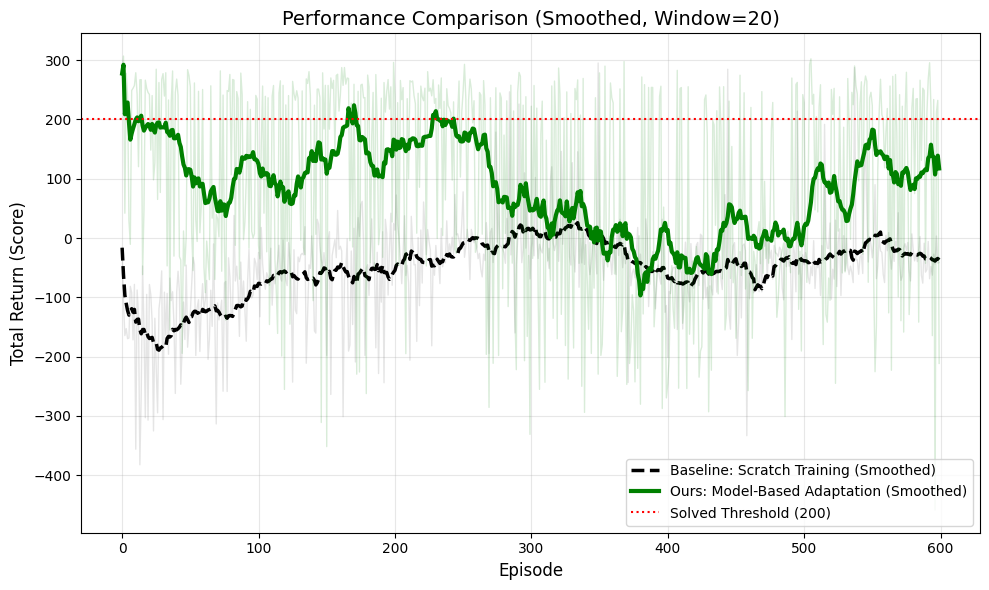

In [15]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd  # Import pandas for easy rolling average

# --- 1. Define a Smoothing Function ---
def smooth(data, window_size=50):
    """
    Calculates the rolling average.
    window_size: Number of episodes to average over (higher = smoother)
    """
    series = pd.Series(data)
    return series.rolling(window=window_size, min_periods=1).mean()

# --- 2. Create the Plot ---
plt.figure(figsize=(10, 6))

# Define window size (Adjust this! 20-50 is usually good for 600 episodes)
WINDOW = 20

# --- Plot Baseline (Scratch) ---
# Optional: Plot raw data faintly in background
plt.plot(scores, color='gray', alpha=0.2, linewidth=1) 
# Plot smoothed trend line
plt.plot(smooth(scores, WINDOW), color='black', linestyle='--', linewidth=2.5, label='Baseline: Scratch Training (Smoothed)')

# --- Plot Ours (Adaptive) ---
# Optional: Plot raw data faintly in background
plt.plot(scores_adaptive, color='green', alpha=0.15, linewidth=1)
# Plot smoothed trend line
plt.plot(smooth(scores_adaptive, WINDOW), color='green', linewidth=3, label='Ours: Model-Based Adaptation (Smoothed)')

# --- Formatting ---
plt.xlabel('Episode', fontsize=12)
plt.ylabel('Total Return (Score)', fontsize=12)
plt.title(f'Performance Comparison (Smoothed, Window={WINDOW})', fontsize=14)
plt.axhline(y=200, color='red', linestyle=':', label='Solved Threshold (200)')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()